# DeepAR — Model Experiment
**Dataset:** Monthly Labor Market (`monthly_labor_market.csv`)  
**Target:** `EMPLOY`  
**Horizon:** 12 months  
**Split:** 80 % train / last 12 months test  
**Metrics:** MAE, MSE  
**Model:** DeepAR (trained from scratch via NeuralForecast)

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/monthly_labor_market.csv")

df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")

df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

df.head()

,ds,POP,LFC,LFPART,RUC,EMPLOY,H,HG,HS
300,1964-01-01,123560.0,72356.0,58.5594,5.6,57487.0,50.8,92.4,39.3
301,1964-02-01,123707.0,72683.0,58.7542,5.4,57753.0,51.5,95.3,39.4
302,1964-03-01,123857.0,72713.0,58.7072,5.4,57897.0,51.5,95.1,39.4
303,1964-04-01,124019.0,73274.0,59.0829,5.3,57922.0,51.7,95.2,39.6
304,1964-05-01,124204.0,73395.0,59.0923,5.1,58089.0,51.9,95.6,39.6


In [3]:
TARGET = "EMPLOY"

In [4]:
split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df  = df.iloc[split:split + 12]

y_true = test_df[TARGET].values

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (596, 9)
Test shape:  (12, 9)


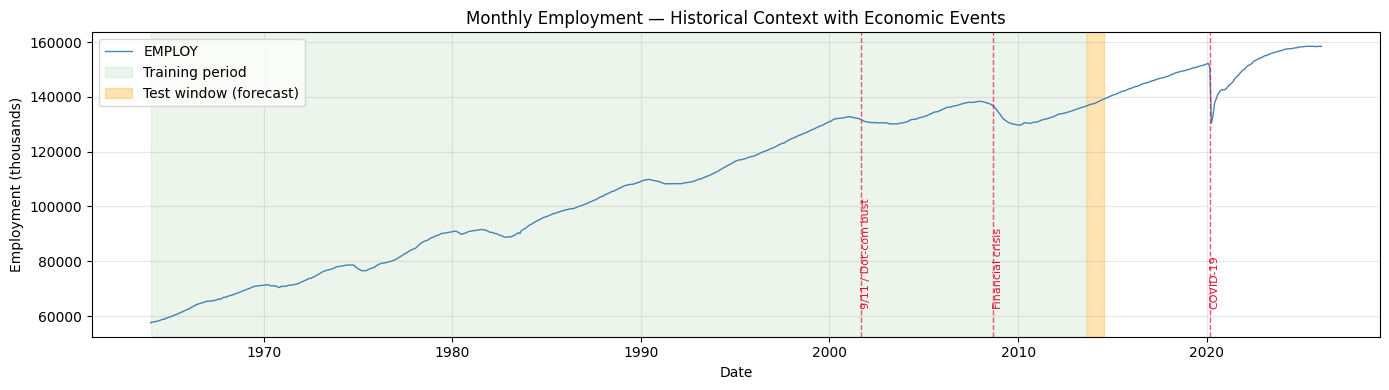

In [5]:
# Historical context: full series with major economic events and train/test boundary
EVENTS = {
    "2001-09-01": "9/11 / Dot-com bust",
    "2008-09-01": "Financial crisis",
    "2020-03-01": "COVID-19",
}

y_max = df[TARGET].max()
y_min = df[TARGET].min()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ds"], df[TARGET], color="steelblue", linewidth=1, label=TARGET)

ax.axvspan(train_df["ds"].iloc[0], train_df["ds"].iloc[-1],
           alpha=0.08, color="green", label="Training period")
ax.axvspan(test_df["ds"].iloc[0], test_df["ds"].iloc[-1],
           alpha=0.3, color="orange", label="Test window (forecast)")

for date, label in EVENTS.items():
    ts = pd.Timestamp(date)
    ax.axvline(ts, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(ts, y_min + (y_max - y_min) * 0.05, label,
            rotation=90, fontsize=8, color="crimson", va="bottom")

ax.set_title("Monthly Employment — Historical Context with Economic Events")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
df_nf = train_df[["ds", TARGET]].copy()
df_nf["unique_id"] = "ts1"
df_nf.rename(columns={TARGET: "y"}, inplace=True)

df_nf.head()

,ds,y,unique_id
300,1964-01-01,57487.0,ts1
301,1964-02-01,57753.0,ts1
302,1964-03-01,57897.0,ts1
303,1964-04-01,57922.0,ts1
304,1964-05-01,58089.0,ts1


In [7]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DeepAR
from neuralforecast.losses.pytorch import DistributionLoss

# scaler_type="standard" normalises the series before training so the
# model does not see raw values in the 100,000s — without this DeepAR
# collapses to near-zero predictions on large-magnitude series.
model = DeepAR(
    h=12,
    input_size=36,
    lstm_n_layers=2,
    lstm_hidden_size=128,
    max_steps=300,
    loss=DistributionLoss(distribution="StudentT"),
    scaler_type="standard",
    learning_rate=1e-3,
    accelerator="cpu",
)

nf = NeuralForecast(models=[model], freq="MS")
nf.fit(df_nf)


/Users/erika/miniconda3/envs/ts-deepar/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-27 16:31:58,692	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-27 16:31:58,826	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
Seed set to 1
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type             | Params | Mode  | FLOPs
-

/Users/erika/miniconda3/envs/ts-deepar/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00,  4.18it/s, v_num=10, train_loss_step=6.750, train_loss_epoch=6.750]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00,  4.16it/s, v_num=10, train_loss_step=6.750, train_loss_epoch=6.750]


In [8]:
forecast = nf.predict()

# With DistributionLoss the point-forecast column is "DeepAR-median"
pred_col = [c for c in forecast.columns if c.startswith("DeepAR")][0]
deepar_pred = forecast[pred_col].values[-12:]

print("Using column:", pred_col)
print("Shape:       ", deepar_pred.shape)
print("Prediction:  ", deepar_pred)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/erika/miniconda3/envs/ts-deepar/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 165.07it/s]
Using column: DeepAR
Shape:        (12,)
Prediction:   [136774.17 136865.72 136895.   136850.19 136728.89 136530.48 136254.94
 135902.05 135471.03 134962.48 134384.81 133760.9 ]


In [9]:
deepar_mae = mean_absolute_error(y_true, deepar_pred)
deepar_mse = mean_squared_error(y_true, deepar_pred)
print(f"DeepAR  MAE: {deepar_mae:.2f}")
print(f"DeepAR  MSE: {deepar_mse:.2f}")

DeepAR  MAE: 2035.78
DeepAR  MSE: 7331065.21


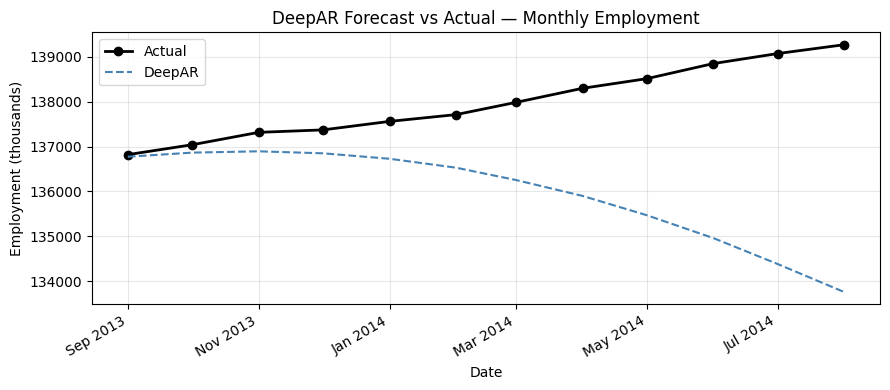


Model               MAE            MSE
--------------------------------------
DeepAR          2035.78     7331065.21


In [10]:
forecast_dates = test_df["ds"].values

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(forecast_dates, y_true,
        color="black", marker="o", label="Actual", linewidth=2)
ax.plot(forecast_dates, deepar_pred,
        linestyle="--", color="steelblue", label="DeepAR", linewidth=1.5)
ax.set_title("DeepAR Forecast vs Actual — Monthly Employment")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\n{'Model':<12} {'MAE':>10} {'MSE':>14}")
print("-" * 38)
print(f"{'DeepAR':<12} {deepar_mae:>10.2f} {deepar_mse:>14.2f}")